In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sc

In [2]:
"""
Self-contained module: all auxiliary functions (wavelengths r and b),
the v2-isolated splits, and the contraction maps H_1, H_2, H_3.

Only dependency: numpy. No local module imports -- everything is in this file,
using the same function bodies translated previously.

Input convention (same as before):
    array = [t, u, v]
    t   = array[0]          (scalar)
    u_1 = array[1][0]
    u_2 = array[1][1]
    v_1 = array[2][0]
    v_2 = array[2][1]

Vector-valued maps return numpy arrays of shape (2,).
The H maps take two such arrays: I_r = [t_r, u_r, v_r], I_b = [t_b, u_b, v_b].
"""
# ---------------------------------------------------------------------------
# Parameters -- set these to your problem's values
# ---------------------------------------------------------------------------
# n_r = 1.5143      # refractive index for wavelength r, must satisfy n_r > 1
# n_b = 1.5224      # refractive index for wavelength b, must satisfy n_b > 1
# rho_0 = 1    # rho_0 > 0
# d_0 = 2*10**(5)      # d_0 > 0
# k_0 = rho_0 / d_0
# w = np.array([0.0, 1.0])   # fixed vector w = (0, 1)
n_r = 1.1400     # refractive index for wavelength r, must satisfy n_r > 1
n_b = 1.8660      # refractive index for wavelength b, must satisfy n_b > 1
rho_0 = 2    # rho_0 > 0
d_0 = 4    # d_0 > 0
k_0 = rho_0 / d_0
w = np.array([0.0, 1.0])   # fixed vector w = (0, 1)

def _unpack(array):
    """Split the input array into t, u_1, u_2, v_1, v_2."""
    t = array[0]
    u_1 = array[1][0]
    u_2 = array[1][1]
    v_1 = array[2][0]
    v_2 = array[2][1]
    return t, u_1, u_2, v_1, v_2


# ===========================================================================
# ===========================================================================
#                       WAVELENGTH r FUNCTIONS
# ===========================================================================
# ===========================================================================

def alpha(array):
    """alpha(u) = (u_1 - sqrt((u_1^2+u_2^2)(n_r^2-1) + u_1^2)) / (u_1^2+u_2^2)."""
    t, u_1, u_2, v_1, v_2 = _unpack(array)
    norm_sq = u_1**2 + u_2**2
    root = np.sqrt(norm_sq * (n_r**2 - 1) + u_1**2)
    return (u_1 - root) / norm_sq


def M_r(array):
    """
    M_r(t,u) = (1/n_r) [ (sin t, cos t)
                         - alpha(u) (u_1 sin t - u_2 cos t,
                                     u_1 cos t + u_2 sin t) ].
    """
    t, u_1, u_2, v_1, v_2 = _unpack(array)
    a = alpha(array)
    vec1 = np.array([np.sin(t), np.cos(t)])
    vec2 = np.array([u_1 * np.sin(t) - u_2 * np.cos(t),
                     u_1 * np.cos(t) + u_2 * np.sin(t)])
    return (vec1 - a * vec2) / n_r


def D_r(array):
    """D_r(t,u) = ((n_r-1) d_0 - u_1 (1 - cos t)) / (n_r - w . M_r(t,u))."""
    t, u_1, u_2, v_1, v_2 = _unpack(array)
    Mr = M_r(array)
    numerator = (n_r - 1) * d_0 - u_1 * (1 - np.cos(t))
    denominator = n_r - np.dot(w, Mr)
    return numerator / denominator


def F_r(array):
    """F_r(t,u) = u_1 (sin t, cos t) + D_r(t,u) M_r(t,u)."""
    t, u_1, u_2, v_1, v_2 = _unpack(array)
    return u_1 * np.array([np.sin(t), np.cos(t)]) + D_r(array) * M_r(array)


def Lambda_2r(array):
    """Lambda_{2,r}(t,u) = sqrt(1 + 1/n_r^2 - (2/n_r) w . M_r(t,u))."""
    Mr = M_r(array)
    return np.sqrt(1.0 + 1.0 / n_r**2 - (2.0 / n_r) * np.dot(w, Mr))


def alpha_tilde(array):
    """
    alpha_tilde(u,v) = (n_r^2-1) *
        ( v_1 + ((u_1 v_1 + u_2 v_2)(n_r^2-1) + u_1 v_1) / R ) * (1/(u_1 + R))^2,
    with R = sqrt((u_1^2+u_2^2)(n_r^2-1) + u_1^2).
    """
    t, u_1, u_2, v_1, v_2 = _unpack(array)
    root = np.sqrt((u_1**2 + u_2**2) * (n_r**2 - 1) + u_1**2)
    middle = v_1 + ((u_1 * v_1 + u_2 * v_2) * (n_r**2 - 1) + u_1 * v_1) / root
    return (n_r**2 - 1) * middle * (1.0 / (u_1 + root))**2


def M_r_tilde(array):
    """
    M_r_tilde(t,u,v) = (1/n_r) [ (cos t, -sin t)
        - alpha_tilde(u,v) (u_1 sin t - u_2 cos t,  u_2 sin t + u_1 cos t)
        - alpha(u) ((u_1 - v_2) cos t + (u_2 + v_1) sin t,
                    (v_2 - u_1) sin t + (v_1 + u_2) cos t) ].
    """
    t, u_1, u_2, v_1, v_2 = _unpack(array)
    a = alpha(array)
    a_t = alpha_tilde(array)
    vec1 = np.array([np.cos(t), -np.sin(t)])
    vec2 = np.array([u_1 * np.sin(t) - u_2 * np.cos(t),
                     u_2 * np.sin(t) + u_1 * np.cos(t)])
    vec3 = np.array([(u_1 - v_2) * np.cos(t) + (u_2 + v_1) * np.sin(t),
                     (v_2 - u_1) * np.sin(t) + (v_1 + u_2) * np.cos(t)])
    return (vec1 - a_t * vec2 - a * vec3) / n_r


def D_r_tilde(array):
    """
    D_r_tilde(t,u,v) =
        [ (v_1 (cos t - 1) - u_1 sin t)(n_r - w . M_r)
          + ((n_r-1) d_0 - u_1 (1 - cos t)) (w . M_r_tilde) ]
        / (n_r - w . M_r)^2.
    """
    t, u_1, u_2, v_1, v_2 = _unpack(array)
    w_dot_Mr = np.dot(w, M_r(array))
    w_dot_Mr_t = np.dot(w, M_r_tilde(array))
    numerator = ((v_1 * (np.cos(t) - 1) - u_1 * np.sin(t)) * (n_r - w_dot_Mr)
                 + ((n_r - 1) * d_0 - u_1 * (1 - np.cos(t))) * w_dot_Mr_t)
    return numerator / (n_r - w_dot_Mr)**2


def F_r_tilde(array):
    """
    F_r_tilde(t,u,v) = u_1 (cos t, -sin t) + v_1 (sin t, cos t)
                       + M_r_tilde(t,u,v) D_r(t,u) + M_r(t,u) D_r_tilde(t,u,v).
    """
    t, u_1, u_2, v_1, v_2 = _unpack(array)
    term1 = u_1 * np.array([np.cos(t), -np.sin(t)])
    term2 = v_1 * np.array([np.sin(t), np.cos(t)])
    return term1 + term2 + M_r_tilde(array) * D_r(array) + M_r(array) * D_r_tilde(array)


def Lambda_2r_tilde(array):
    """Lambda_2r_tilde(t,u,v) = -(1/n_r) (w . M_r_tilde) / Lambda_2r(t,u)."""
    return -(1.0 / n_r) * np.dot(w, M_r_tilde(array)) / Lambda_2r(array)


# ===========================================================================
# ===========================================================================
#                       WAVELENGTH b FUNCTIONS
# ===========================================================================
# ===========================================================================

def alpha_b(array):
    """alpha_b(u) = (u_1 - sqrt((u_1^2+u_2^2)(n_b^2-1) + u_1^2)) / (u_1^2+u_2^2)."""
    t, u_1, u_2, v_1, v_2 = _unpack(array)
    norm_sq = u_1**2 + u_2**2
    root = np.sqrt(norm_sq * (n_b**2 - 1) + u_1**2)
    return (u_1 - root) / norm_sq


def M_b(array):
    """
    M_b(t,u) = (1/n_b) [ (sin t, cos t)
                         - alpha_b(u) (u_1 sin t - u_2 cos t,
                                       u_1 cos t + u_2 sin t) ].
    """
    t, u_1, u_2, v_1, v_2 = _unpack(array)
    a = alpha_b(array)
    vec1 = np.array([np.sin(t), np.cos(t)])
    vec2 = np.array([u_1 * np.sin(t) - u_2 * np.cos(t),
                     u_1 * np.cos(t) + u_2 * np.sin(t)])
    return (vec1 - a * vec2) / n_b


def D_b(array):
    """D_b(t,u) = ((n_b-1) d_0 - u_1 (1 - cos t)) / (n_b - w . M_b(t,u))."""
    t, u_1, u_2, v_1, v_2 = _unpack(array)
    Mb = M_b(array)
    numerator = (n_b - 1) * d_0 - u_1 * (1 - np.cos(t))
    denominator = n_b - np.dot(w, Mb)
    return numerator / denominator


def F_b(array):
    """F_b(t,u) = u_1 (sin t, cos t) + D_b(t,u) M_b(t,u)."""
    t, u_1, u_2, v_1, v_2 = _unpack(array)
    return u_1 * np.array([np.sin(t), np.cos(t)]) + D_b(array) * M_b(array)


def Lambda_2b(array):
    """Lambda_{2,b}(t,u) = sqrt(1 + 1/n_b^2 - (2/n_b) w . M_b(t,u))."""
    Mb = M_b(array)
    return np.sqrt(1.0 + 1.0 / n_b**2 - (2.0 / n_b) * np.dot(w, Mb))


def alpha_tilde_b(array):
    """
    alpha_tilde_b(u,v) = (n_b^2-1) *
        ( v_1 + ((u_1 v_1 + u_2 v_2)(n_b^2-1) + u_1 v_1) / R ) * (1/(u_1 + R))^2,
    with R = sqrt((u_1^2+u_2^2)(n_b^2-1) + u_1^2).
    """
    t, u_1, u_2, v_1, v_2 = _unpack(array)
    root = np.sqrt((u_1**2 + u_2**2) * (n_b**2 - 1) + u_1**2)
    middle = v_1 + ((u_1 * v_1 + u_2 * v_2) * (n_b**2 - 1) + u_1 * v_1) / root
    return (n_b**2 - 1) * middle * (1.0 / (u_1 + root))**2


def M_b_tilde(array):
    """
    M_b_tilde(t,u,v) = (1/n_b) [ (cos t, -sin t)
        - alpha_tilde_b(u,v) (u_1 sin t - u_2 cos t,  u_2 sin t + u_1 cos t)
        - alpha_b(u) ((u_1 - v_2) cos t + (u_2 + v_1) sin t,
                      (v_2 - u_1) sin t + (v_1 + u_2) cos t) ].
    """
    t, u_1, u_2, v_1, v_2 = _unpack(array)
    a = alpha_b(array)
    a_t = alpha_tilde_b(array)
    vec1 = np.array([np.cos(t), -np.sin(t)])
    vec2 = np.array([u_1 * np.sin(t) - u_2 * np.cos(t),
                     u_2 * np.sin(t) + u_1 * np.cos(t)])
    vec3 = np.array([(u_1 - v_2) * np.cos(t) + (u_2 + v_1) * np.sin(t),
                     (v_2 - u_1) * np.sin(t) + (v_1 + u_2) * np.cos(t)])
    return (vec1 - a_t * vec2 - a * vec3) / n_b


def D_b_tilde(array):
    """
    D_b_tilde(t,u,v) =
        [ (v_1 (cos t - 1) - u_1 sin t)(n_b - w . M_b)
          + ((n_b-1) d_0 - u_1 (1 - cos t)) (w . M_b_tilde) ]
        / (n_b - w . M_b)^2.
    """
    t, u_1, u_2, v_1, v_2 = _unpack(array)
    w_dot_Mb = np.dot(w, M_b(array))
    w_dot_Mb_t = np.dot(w, M_b_tilde(array))
    numerator = ((v_1 * (np.cos(t) - 1) - u_1 * np.sin(t)) * (n_b - w_dot_Mb)
                 + ((n_b - 1) * d_0 - u_1 * (1 - np.cos(t))) * w_dot_Mb_t)
    return numerator / (n_b - w_dot_Mb)**2


def F_b_tilde(array):
    """
    F_b_tilde(t,u,v) = u_1 (cos t, -sin t) + v_1 (sin t, cos t)
                       + M_b_tilde(t,u,v) D_b(t,u) + M_b(t,u) D_b_tilde(t,u,v).
    """
    t, u_1, u_2, v_1, v_2 = _unpack(array)
    term1 = u_1 * np.array([np.cos(t), -np.sin(t)])
    term2 = v_1 * np.array([np.sin(t), np.cos(t)])
    return term1 + term2 + M_b_tilde(array) * D_b(array) + M_b(array) * D_b_tilde(array)


def Lambda_2b_tilde(array):
    """Lambda_2b_tilde(t,u,v) = -(1/n_b) (w . M_b_tilde) / Lambda_2b(t,u)."""
    return -(1.0 / n_b) * np.dot(w, M_b_tilde(array)) / Lambda_2b(array)


# ===========================================================================
# ===========================================================================
#         v2-ISOLATED SPLITS (wavelength r):
#         f_tilde(t,u,v) = v_2 * f_tilde_v2 + f_tilde_others
# ===========================================================================
# ===========================================================================

def alpha_tilde_v2(array):
    """
    Coefficient of v_2 in alpha_tilde:
    alpha_tilde_v2(u) = (n_r^2-1) * (u_2 (n_r^2-1) / R) * (1/(u_1+R))^2.
    """
    t, u_1, u_2, v_1, v_2 = _unpack(array)
    R = np.sqrt((u_1**2 + u_2**2) * (n_r**2 - 1) + u_1**2)
    return (n_r**2 - 1) * (u_2 * (n_r**2 - 1) / R) * (1.0 / (u_1 + R))**2


def alpha_tilde_others(array):
    """
    v_2-free part of alpha_tilde (= alpha_tilde with v_2 set to 0):
    (n_r^2-1) * ( v_1 + (u_1 v_1 (n_r^2-1) + u_1 v_1)/R ) * (1/(u_1+R))^2.
    """
    t, u_1, u_2, v_1, v_2 = _unpack(array)
    R = np.sqrt((u_1**2 + u_2**2) * (n_r**2 - 1) + u_1**2)
    middle = v_1 + (u_1 * v_1 * (n_r**2 - 1) + u_1 * v_1) / R
    return (n_r**2 - 1) * middle * (1.0 / (u_1 + R))**2


def M_r_tilde_v2(array):
    """
    M_r_tilde_v2(t,u,v) = (1/n_r) [ - alpha_tilde_v2(u) (u_1 sin t - u_2 cos t,
                                                         u_2 sin t + u_1 cos t)
                                    - alpha(u) (-cos t, sin t) ].
    """
    t, u_1, u_2, v_1, v_2 = _unpack(array)
    a = alpha(array)
    a_v2 = alpha_tilde_v2(array)
    vec2 = np.array([u_1 * np.sin(t) - u_2 * np.cos(t),
                     u_2 * np.sin(t) + u_1 * np.cos(t)])
    vec3_v2 = np.array([-np.cos(t), np.sin(t)])
    return (-a_v2 * vec2 - a * vec3_v2) / n_r


def M_r_tilde_others(array):
    """
    M_r_tilde_others(t,u,v) = (1/n_r) [ (cos t, -sin t)
        - alpha_tilde_others(u,v) (u_1 sin t - u_2 cos t,  u_2 sin t + u_1 cos t)
        - alpha(u) (u_1 cos t + (u_2+v_1) sin t,  -u_1 sin t + (v_1+u_2) cos t) ].
    """
    t, u_1, u_2, v_1, v_2 = _unpack(array)
    a = alpha(array)
    a_oth = alpha_tilde_others(array)
    vec1 = np.array([np.cos(t), -np.sin(t)])
    vec2 = np.array([u_1 * np.sin(t) - u_2 * np.cos(t),
                     u_2 * np.sin(t) + u_1 * np.cos(t)])
    vec3_oth = np.array([u_1 * np.cos(t) + (u_2 + v_1) * np.sin(t),
                         -u_1 * np.sin(t) + (v_1 + u_2) * np.cos(t)])
    return (vec1 - a_oth * vec2 - a * vec3_oth) / n_r


def D_r_tilde_v2(array):
    """
    D_r_tilde_v2 = ((n_r-1) d_0 - u_1 (1 - cos t)) (w . M_r_tilde_v2)
                   / (n_r - w . M_r)^2.
    """
    t, u_1, u_2, v_1, v_2 = _unpack(array)
    w_dot_Mr = np.dot(w, M_r(array))
    w_dot_Mv2 = np.dot(w, M_r_tilde_v2(array))
    return ((n_r - 1) * d_0 - u_1 * (1 - np.cos(t))) * w_dot_Mv2 / (n_r - w_dot_Mr)**2


def D_r_tilde_others(array):
    """
    D_r_tilde_others = [ (v_1 (cos t - 1) - u_1 sin t)(n_r - w . M_r)
                         + ((n_r-1) d_0 - u_1 (1 - cos t)) (w . M_r_tilde_others) ]
                       / (n_r - w . M_r)^2.
    """
    t, u_1, u_2, v_1, v_2 = _unpack(array)
    w_dot_Mr = np.dot(w, M_r(array))
    w_dot_Moth = np.dot(w, M_r_tilde_others(array))
    numerator = ((v_1 * (np.cos(t) - 1) - u_1 * np.sin(t)) * (n_r - w_dot_Mr)
                 + ((n_r - 1) * d_0 - u_1 * (1 - np.cos(t))) * w_dot_Moth)
    return numerator / (n_r - w_dot_Mr)**2


def F_r_tilde_v2(array):
    """F_r_tilde_v2 = M_r_tilde_v2 * D_r + M_r * D_r_tilde_v2."""
    return M_r_tilde_v2(array) * D_r(array) + M_r(array) * D_r_tilde_v2(array)


def F_r_tilde_others(array):
    """
    F_r_tilde_others = u_1 (cos t, -sin t) + v_1 (sin t, cos t)
                       + M_r_tilde_others * D_r + M_r * D_r_tilde_others.
    """
    t, u_1, u_2, v_1, v_2 = _unpack(array)
    term1 = u_1 * np.array([np.cos(t), -np.sin(t)])
    term2 = v_1 * np.array([np.sin(t), np.cos(t)])
    return (term1 + term2
            + M_r_tilde_others(array) * D_r(array)
            + M_r(array) * D_r_tilde_others(array))


def Lambda_2r_tilde_v2(array):
    """Lambda_2r_tilde_v2 = -(1/n_r) (w . M_r_tilde_v2) / Lambda_2r."""
    return -(1.0 / n_r) * np.dot(w, M_r_tilde_v2(array)) / Lambda_2r(array)


def Lambda_2r_tilde_others(array):
    """Lambda_2r_tilde_others = -(1/n_r) (w . M_r_tilde_others) / Lambda_2r."""
    return -(1.0 / n_r) * np.dot(w, M_r_tilde_others(array)) / Lambda_2r(array)


# ===========================================================================
# ===========================================================================
#               CONTRACTION MAPS H_1, H_2, H_3
#               I_r = [t_r, u_r, v_r],  I_b = [t_b, u_b, v_b]
# ===========================================================================
# ===========================================================================

def H_1(I_r, I_b):
    """H_1(I_r, I_b) = F_r_tilde_1(I_r) / F_b_tilde_1(I_b)."""
    return F_r_tilde(I_r)[0] / F_b_tilde(I_b)[0]


def H_2(I_r, I_b):
    """H_2(I_r, I_b) = u_{r2}  (second component of u_r)."""
    return I_r[1][1]


def H_3(I_r, I_b):
    """
    H_3(I_r, I_b) = the value of v_2 (= z_3'(t)) isolated from

        F_r_tilde_1(I_r) (M_r1(I_r) Lambda_2b_tilde(I_b) - M_b1_tilde(I_b) Lambda_2r(I_r))
      = F_b_tilde_1(I_b) (M_r1_tilde(I_r) Lambda_2b(I_b) - M_b1(I_b) Lambda_2r_tilde(I_r)),

    namely

        [ F_b_tilde_1(I_b) (M_r1_tilde_others(I_r) Lambda_2b(I_b)
                            - M_b1(I_b) Lambda_2r_tilde_others(I_r))
          - F_r_tilde_1_others(I_r) (M_r1(I_r) Lambda_2b_tilde(I_b)
                                     - M_b1_tilde(I_b) Lambda_2r(I_r)) ]
        /
        [ F_r_tilde_1_v2(I_r) (M_r1(I_r) Lambda_2b_tilde(I_b)
                               - M_b1_tilde(I_b) Lambda_2r(I_r))
          - F_b_tilde_1(I_b) (M_r1_tilde_v2(I_r) Lambda_2b(I_b)
                              - M_b1(I_b) Lambda_2r_tilde_v2(I_r)) ].
    """
    # --- pieces evaluated at I_r (wavelength r) ---
    Mr1 = M_r(I_r)[0]                          # M_r1(I_r)
    Lam_r = Lambda_2r(I_r)                     # Lambda_2r(I_r)
    Mr1_oth = M_r_tilde_others(I_r)[0]         # M_r1_tilde_others(I_r)
    Mr1_v2 = M_r_tilde_v2(I_r)[0]              # M_r1_tilde_v2(I_r)
    LamT_r_oth = Lambda_2r_tilde_others(I_r)   # Lambda_2r_tilde_others(I_r)
    LamT_r_v2 = Lambda_2r_tilde_v2(I_r)        # Lambda_2r_tilde_v2(I_r)
    Fr1_oth = F_r_tilde_others(I_r)[0]         # F_r1_tilde_others(I_r)
    Fr1_v2 = F_r_tilde_v2(I_r)[0]              # F_r1_tilde_v2(I_r)

    # --- pieces evaluated at I_b (wavelength b, full functions) ---
    Fb1_t = F_b_tilde(I_b)[0]                  # F_b1_tilde(I_b)
    Mb1 = M_b(I_b)[0]                          # M_b1(I_b)
    Mb1_t = M_b_tilde(I_b)[0]                  # M_b1_tilde(I_b)
    Lam_b = Lambda_2b(I_b)                     # Lambda_2b(I_b)
    LamT_b = Lambda_2b_tilde(I_b)              # Lambda_2b_tilde(I_b)

    # common bracket appearing in numerator and denominator
    bracket = Mr1 * LamT_b - Mb1_t * Lam_r     # M_r1 Lambda_2b_tilde - M_b1_tilde Lambda_2r

    numerator = (Fb1_t * (Mr1_oth * Lam_b - Mb1 * LamT_r_oth)
                 - Fr1_oth * bracket)
    denominator = (Fr1_v2 * bracket
                   - Fb1_t * (Mr1_v2 * Lam_b - Mb1 * LamT_r_v2))
    return numerator / denominator


# ===========================================================================
# Sanity checks
# ===========================================================================
# if __name__ == "__main__":
#     rng = np.random.default_rng(0)

#     print("=== Linearity check: f_tilde == v2 * f_v2 + f_others (random points) ===")
#     for trial in range(5):
#         t = rng.uniform(-1, 1)
#         u = rng.uniform(0.5, 2.0, size=2)
#         v = rng.uniform(-1, 1, size=2)
#         arr = [t, u, v]
#         v2 = v[1]

#         checks = {
#             "alpha_tilde": (alpha_tilde(arr),
#                             v2 * alpha_tilde_v2(arr) + alpha_tilde_others(arr)),
#             "M_r_tilde":   (M_r_tilde(arr),
#                             v2 * M_r_tilde_v2(arr) + M_r_tilde_others(arr)),
#             "D_r_tilde":   (D_r_tilde(arr),
#                             v2 * D_r_tilde_v2(arr) + D_r_tilde_others(arr)),
#             "F_r_tilde":   (F_r_tilde(arr),
#                             v2 * F_r_tilde_v2(arr) + F_r_tilde_others(arr)),
#             "Lambda_2r_tilde": (Lambda_2r_tilde(arr),
#                                 v2 * Lambda_2r_tilde_v2(arr) + Lambda_2r_tilde_others(arr)),
#         }
#         ok = all(np.allclose(full, split, rtol=1e-12, atol=1e-12)
#                  for full, split in checks.values())
#         print(f"  trial {trial}: all splits match -> {ok}")

#     print()
#     print("=== H_3 consistency check ===")
#     print("Plug v_r2 = H_3(I_r, I_b) back into I_r; then the identity")
#     print("  F_r_tilde_1 (M_r1 LamT_b - M_b1_t Lam_r) "
#           "= F_b_tilde_1 (M_r1_tilde Lam_b - M_b1 LamT_r)")
#     print("should hold exactly.")
#     for trial in range(3):
#         I_r = [rng.uniform(-1, 1), rng.uniform(0.5, 2.0, 2), rng.uniform(-1, 1, 2)]
#         I_b = [rng.uniform(-1, 1), rng.uniform(0.5, 2.0, 2), rng.uniform(-1, 1, 2)]

#         v2_star = H_3(I_r, I_b)
#         I_r_star = [I_r[0], I_r[1], np.array([I_r[2][0], v2_star])]

#         lhs = (F_r_tilde(I_r_star)[0]
#                * (M_r(I_r_star)[0] * Lambda_2b_tilde(I_b)
#                   - M_b_tilde(I_b)[0] * Lambda_2r(I_r_star)))
#         rhs = (F_b_tilde(I_b)[0]
#                * (M_r_tilde(I_r_star)[0] * Lambda_2b(I_b)
#                   - M_b(I_b)[0] * Lambda_2r_tilde(I_r_star)))
#         print(f"  trial {trial}: v2* = {v2_star: .6f}, residual = {lhs - rhs: .3e}")

#     print()
#     print("=== H maps smoke test ===")
#     I_r = [0.3, np.array([1.0, 0.5]), np.array([0.2, -0.1])]
#     I_b = [0.25, np.array([1.1, 0.4]), np.array([0.15, -0.05])]
#     print("H_1 =", H_1(I_r, I_b))
#     print("H_2 =", H_2(I_r, I_b))
#     print("H_3 =", H_3(I_r, I_b))

In [3]:
# ===========================================================================
# Admissible point P  (eq:admissible P)
# ===========================================================================

def Delta_r():
    """Delta_r = n_r / (n_r - 1)."""
    return n_r / (n_r - 1)


def Delta_b():
    """Delta_b = n_b / (n_b - 1)."""
    return n_b / (n_b - 1)


def P(k_0):
    """
    P = ( (Db - Dr + S) / (Dr - Db + S),
          0,
          ((Db + Dr + S) / 2) * rho_0 ),
    where Dr = Delta_r, Db = Delta_b, k_0 = rho_0 / d_0,
    and S = sqrt((Db - Dr)^2 - 4 k_0 Db Dr).
    Returns np.array([P_1, P_2, P_3]).
    """
    Dr = Delta_r()
    Db = Delta_b()
    # k_0 = rho_0 / d_0

    discriminant = (Db - Dr)**2 - 4.0 * k_0 * Db * Dr
    if discriminant < 0:
        raise ValueError(
            f"Negative discriminant ({discriminant:.6e}): "
            "(Delta_b - Delta_r)^2 - 4 k_0 Delta_b Delta_r < 0 for the "
            "current n_r, n_b, rho_0, d_0 -- P is not real."
        )
    S = np.sqrt(discriminant)

    P_1 = (Db - Dr + S) / (Dr - Db + S)
    P_2 = 0.0
    P_3 = ((Db + Dr + S) / 2.0) * rho_0

    return np.array([P_1, P_2, P_3])

In [33]:
from scipy.integrate import quad
from scipy.integrate import quad_vec
from scipy.interpolate import CubicSpline

delta = 0.95/4
dinterval = np.linspace(-delta, delta, 300)
def findingsolution(k_0, n , tol):
    def g(t):
        return t*P(k_0)
    def dg(t):
        return P(k_0)

    def h_t(t, g, dg):
        f = g(t) 
        df = dg(t)
        h_2 = f[2] #z_2'(t)=z_3(t)

        I_r = [t, [f[1]+rho_0, f[2]], [h_2, 0]]
        I_b = [f[0], [g(f[0])[1]+rho_0, g(f[0])[2]], dg(f[0])[1:]] 
        
        h_3 = H_3(I_r, I_b)

        I_r[2][1] = h_3 # z_3'(t)=H_3(t)

        h_1 = H_1(I_r, I_b)
        return np.array([h_1, h_2, h_3])
    
    def H_t(t):
        return h_t(t, g, dg)

    k = dinterval.size
    Z_array = np.zeros((n, k , 3))
    
    for i in np.arange( n):
        print(f"i={i}")
        if i == 0:
            for j in np.arange(k):
                Z_array[i][j] = g(dinterval[j])
            continue   

        for j in np.arange(k):
            print(f"j={j}")
            Z_array[i][j], err, info = quad_vec(H_t, 0, dinterval[j], full_output= True, limit=n, epsabs = tol, epsrel = tol )
            print("Integral done")
            print(f"Final error reached: {err}")
             
            if not info.success:
                print(f"Convergence failed! Message: {info.message}")
                
                break
            
        if not info.success:
            break
        
        diff = Z_array[i] - Z_array[i-1]

        # Euclidean norm at each time point, shape (N,)
        norms = np.linalg.norm(diff, axis=1)

        # Worst case over the interval
        max_norm = np.max(norms)      
        if max_norm < tol:
            break
        else:
            print(f'norms:{norms}')
            print(f"max_norm = {max_norm}")

        g = CubicSpline(dinterval, Z_array[i])
        dg = g.derivative()
        print("interpolation done")
        def H_t(t):
                return h_t(t, g, dg)  
                      
    return Z_array, i

arr2, index = findingsolution(k_0=k_0,n = 1000, tol = 1e-6)
 

i=0
i=1
j=0
Integral done
Final error reached: 2.0071385802692458e-12
j=1
Integral done
Final error reached: 1.0989851411628658e-12
j=2
Integral done
Final error reached: 6.369053125196232e-13
j=3
Integral done
Final error reached: 3.994120039571743e-13
j=4
Integral done
Final error reached: 2.760637263881141e-13
j=5
Integral done
Final error reached: 2.11199274934993e-13
j=6
Integral done
Final error reached: 1.7654348661513928e-13
j=7
Integral done
Final error reached: 1.6943402357395054e-13
j=8
Integral done
Final error reached: 1.6773529842633424e-13
j=9
Integral done
Final error reached: 1.6605308555796824e-13
j=10
Integral done
Final error reached: 1.643867951194975e-13
j=11
Integral done
Final error reached: 1.627358788789696e-13
j=12
Integral done
Final error reached: 1.610998260806385e-13
j=13
Integral done
Final error reached: 1.5947815980693372e-13
j=14
Integral done
Final error reached: 1.578704337714953e-13
j=15
Integral done
Final error reached: 1.562762294836313e-13
j=16

In [34]:
# n_r = 1.1400     # refractive index for wavelength r, must satisfy n_r > 1
# n_b = 1.8660      # refractive index for wavelength b, must satisfy n_b > 1
# rho_0 = 1    # rho_0 > 0
# d_0 = 2     # d_0 > 0
# k_0 = rho_0 / d_0
# w = np.array([0.0, 1.0])   # fixed vector w = (0, 1)

rho_array = arr2[index,:,1] + rho_0
rho_array 

array([2.72816118, 2.71422929, 2.70056243, 2.68715338, 2.67399522,
       2.66108132, 2.64840532, 2.63596111, 2.6237428 , 2.61174476,
       2.59996156, 2.58838796, 2.57701894, 2.56584965, 2.55487541,
       2.54409174, 2.53349427, 2.52307883, 2.51284136, 2.50277797,
       2.49288486, 2.48315841, 2.47359508, 2.46419146, 2.45494426,
       2.44585027, 2.43690642, 2.42810971, 2.41945723, 2.41094619,
       2.40257385, 2.39433758, 2.38623483, 2.3782631 , 2.37042   ,
       2.36270317, 2.35511036, 2.34763936, 2.34028804, 2.33305431,
       2.32593615, 2.31893161, 2.31203877, 2.30525579, 2.29858086,
       2.29201222, 2.28554818, 2.27918707, 2.27292728, 2.26676725,
       2.26070543, 2.25474034, 2.24887054, 2.24309461, 2.23741118,
       2.23181891, 2.22631649, 2.22090266, 2.21557618, 2.21033584,
       2.20518047, 2.20010892, 2.19512007, 2.19021284, 2.18538617,
       2.18063902, 2.17597037, 2.17137926, 2.16686472, 2.16242581,
       2.15806162, 2.15377126, 2.14955386, 2.14540858, 2.14133

In [35]:
xrho = np.zeros((dinterval.size, 2))
for i in np.arange(dinterval.size):
    xrho[i] =rho_array[i]*np.array([np.sin(dinterval[i]), np.cos(dinterval[i])])

In [36]:
xrho = rho_array[:, np.newaxis] * np.column_stack([np.sin(dinterval), np.cos(dinterval)])

In [37]:
xrho

array([[-6.41864142e-01,  2.65157950e+00],
       [-6.34394669e-01,  2.63904984e+00],
       [-6.27028169e-01,  2.62676096e+00],
       [-6.19761784e-01,  2.61470622e+00],
       [-6.12592768e-01,  2.60287928e+00],
       [-6.05518482e-01,  2.59127404e+00],
       [-5.98536387e-01,  2.57988468e+00],
       [-5.91644038e-01,  2.56870557e+00],
       [-5.84839082e-01,  2.55773133e+00],
       [-5.78119250e-01,  2.54695678e+00],
       [-5.71482356e-01,  2.53637695e+00],
       [-5.64926290e-01,  2.52598704e+00],
       [-5.58449017e-01,  2.51578244e+00],
       [-5.52048570e-01,  2.50575873e+00],
       [-5.45723051e-01,  2.49591160e+00],
       [-5.39470625e-01,  2.48623696e+00],
       [-5.33289519e-01,  2.47673081e+00],
       [-5.27178014e-01,  2.46738933e+00],
       [-5.21134452e-01,  2.45820882e+00],
       [-5.15157224e-01,  2.44918570e+00],
       [-5.09244773e-01,  2.44031652e+00],
       [-5.03395590e-01,  2.43159795e+00],
       [-4.97608214e-01,  2.42302676e+00],
       [-4.

In [38]:
d_array = np.zeros((rho_array.size))
for i in np.arange(rho_array.size):
    d_array[i] = D_r([dinterval[i],[rho_array[i], arr2[index,i,2]],[0,0]])

In [39]:
d_array

array([3.43312249, 3.4435818 , 3.45385719, 3.46395319, 3.4738742 ,
       3.48362441, 3.49320786, 3.50262846, 3.51188995, 3.52099597,
       3.52994998, 3.53875536, 3.54741536, 3.55593312, 3.56431166,
       3.57255391, 3.58066271, 3.58864079, 3.5964908 , 3.60421531,
       3.61181679, 3.61929766, 3.62666024, 3.63390679, 3.6410395 ,
       3.64806049, 3.65497182, 3.66177548, 3.66847342, 3.67506751,
       3.68155959, 3.68795143, 3.69424476, 3.70044124, 3.70654251,
       3.71255015, 3.71846571, 3.72429067, 3.7300265 , 3.73567461,
       3.74123639, 3.74671317, 3.75210627, 3.75741695, 3.76264645,
       3.76779599, 3.77286673, 3.77785983, 3.78277639, 3.78761752,
       3.79238426, 3.79707766, 3.80169872, 3.80624842, 3.81072772,
       3.81513756, 3.81947885, 3.82375247, 3.82795931, 3.83210019,
       3.83617595, 3.8401874 , 3.84413531, 3.84802047, 3.85184361,
       3.85560547, 3.85930677, 3.8629482 , 3.86653043, 3.87005415,
       3.87351998, 3.87692858, 3.88028054, 3.88357649, 3.88681

In [40]:
M_array = np.zeros((rho_array.size,2))
for i in np.arange(rho_array.size):
    M_array[i] = M_r([dinterval[i],[rho_array[i], arr2[index,i,2]],[0,0]])

In [41]:
F_array = np.zeros((rho_array.size,2))
for i in np.arange(rho_array.size):
    F_array[i] = F_r([dinterval[i],[rho_array[i], arr2[index,i,2]],[0,0]])

In [42]:
F_array

array([[-5.03703112e-01,  6.08192082e+00],
       [-4.97575596e-01,  6.07991255e+00],
       [-4.91539348e-01,  6.07795962e+00],
       [-4.85591763e-01,  6.07606002e+00],
       [-4.79730343e-01,  6.07421181e+00],
       [-4.73952682e-01,  6.07241315e+00],
       [-4.68256471e-01,  6.07066229e+00],
       [-4.62639486e-01,  6.06895755e+00],
       [-4.57099586e-01,  6.06729735e+00],
       [-4.51634709e-01,  6.06568016e+00],
       [-4.46242868e-01,  6.06410453e+00],
       [-4.40922147e-01,  6.06256907e+00],
       [-4.35670700e-01,  6.06107245e+00],
       [-4.30486742e-01,  6.05961340e+00],
       [-4.25368554e-01,  6.05819070e+00],
       [-4.20314471e-01,  6.05680319e+00],
       [-4.15322888e-01,  6.05544976e+00],
       [-4.10392251e-01,  6.05412933e+00],
       [-4.05521060e-01,  6.05284087e+00],
       [-4.00707860e-01,  6.05158342e+00],
       [-3.95951247e-01,  6.05035601e+00],
       [-3.91249858e-01,  6.04915775e+00],
       [-3.86602376e-01,  6.04798776e+00],
       [-3.

In [43]:
def refract(x, nu, n1, n2):
    """
    Formula
    -------
    mu = x.nu - sqrt((n2/n1)^2 - 1 + (x.nu)^2)
    m  = (n1/n2) * (x - mu * nu)
    """
    x  = np.asarray(x,  dtype=float)
    nu = np.asarray(nu, dtype=float)

    x_dot_nu = np.dot(x, nu)

    discriminant = (n2/n1)**2 - 1.0 + x_dot_nu**2

    if discriminant < 0:
        return None                     # total internal reflection

    mu = x_dot_nu - np.sqrt(discriminant)
    m  = (n1/n2) * (x - mu * nu)

    return m / np.linalg.norm(m)       # normalise for safety

In [44]:
h = dinterval[1] -dinterval[0]
w_array = np.zeros((dinterval.size,2))
for i in np.arange(dinterval.size-1):
    tangent = (F_array[i+1] - F_array[i])
    normal  = np.array([-tangent[1], tangent[0]])   # rotate 90°
    normal  = normal / np.linalg.norm(normal)
    w_array[i] =refract(M_array[i], normal ,n_r,1 )


In [45]:
w_array

array([[2.95726150e-04, 9.99999956e-01],
       [2.90674884e-04, 9.99999958e-01],
       [2.85784368e-04, 9.99999959e-01],
       [2.81057608e-04, 9.99999961e-01],
       [2.76482695e-04, 9.99999962e-01],
       [2.72056074e-04, 9.99999963e-01],
       [2.67768777e-04, 9.99999964e-01],
       [2.63613754e-04, 9.99999965e-01],
       [2.59586155e-04, 9.99999966e-01],
       [2.55680765e-04, 9.99999967e-01],
       [2.51892093e-04, 9.99999968e-01],
       [2.48216428e-04, 9.99999969e-01],
       [2.44648132e-04, 9.99999970e-01],
       [2.41180701e-04, 9.99999971e-01],
       [2.37812470e-04, 9.99999972e-01],
       [2.34541390e-04, 9.99999972e-01],
       [2.31361043e-04, 9.99999973e-01],
       [2.28267792e-04, 9.99999974e-01],
       [2.25259108e-04, 9.99999975e-01],
       [2.22332011e-04, 9.99999975e-01],
       [2.19483739e-04, 9.99999976e-01],
       [2.16709913e-04, 9.99999977e-01],
       [2.14009287e-04, 9.99999977e-01],
       [2.11378912e-04, 9.99999978e-01],
       [2.088162

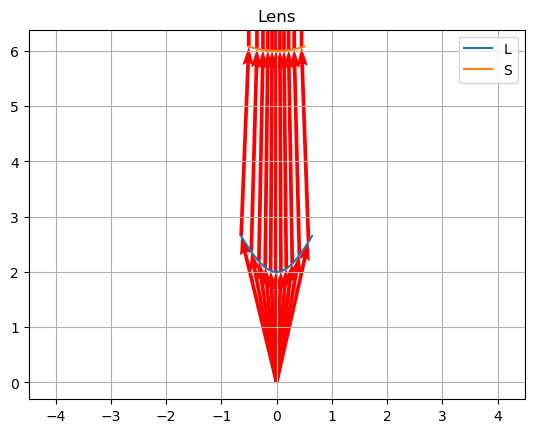

In [48]:
step = 29
up = 300
low = 0
xr_vectors = xrho[low:up][::step]
m_vectors  = M_array[low:up][::step]
d_vectors  = d_array[low:up][::step]
w_vectors = w_array[low:up][::step]
f_vectors = F_array[low:up][::step]
plt.figure()
plt.plot((xrho[low:up])[:,0],(xrho[low:up])[:,1], label = 'L')
plt.plot((F_array[low:up])[:,0],(F_array[low:up])[:,1], label = 'S')


for i in np.arange(dinterval[low:up][::step].size):
    plt.quiver(0, 0, xr_vectors[i,0], xr_vectors[i,1], angles='xy', scale_units='xy', scale=1, color='red')
    plt.quiver(xr_vectors[i,0], xr_vectors[i,1], d_vectors[i] * m_vectors[i, 0], d_vectors[i] * m_vectors[i, 1], angles='xy', scale_units='xy', scale=1, color='red')
    plt.quiver(f_vectors[i,0], f_vectors[i,1], w_vectors[i,0], w_vectors[i,1], angles='xy', scale_units='xy', scale=1, color='red')


plt.legend()
plt.title("Lens")
plt.grid(True)
plt.axis('equal')
# plt.gca().set_aspect('equal', adjustable='box')
plt.show()

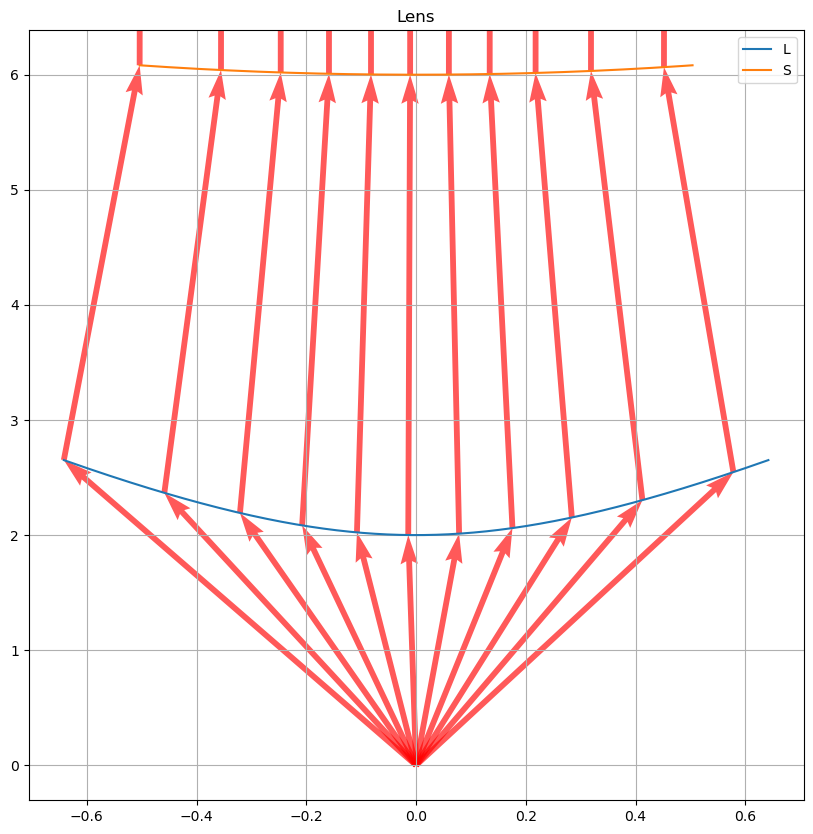

In [47]:
fig, ax = plt.subplots(figsize=(10, 10), dpi=100)
ax.plot((xrho[low:up])[:,0],(xrho[low:up])[:,1], label = 'L')
ax.plot((F_array[low:up])[:,0],(F_array[low:up])[:,1], label = 'S')

for i in np.arange(xr_vectors.shape[0]):
    ax.quiver(0, 0,
              xr_vectors[i, 0], xr_vectors[i, 1],
              angles='xy', scale_units='xy', scale=1, color='red', alpha=0.65)
    ax.quiver(xr_vectors[i, 0], xr_vectors[i, 1],
              d_vectors[i] * m_vectors[i, 0],
              d_vectors[i] * m_vectors[i, 1],
              angles='xy', scale_units='xy', scale=1, color='red', alpha=0.65)
    ax.quiver(f_vectors[i, 0], f_vectors[i, 1],
               w_vectors[i, 0],
               w_vectors[i, 1],
              angles='xy', scale_units='xy', scale=1, color='red', alpha=0.65)

# ax.set_xlim(-0.25, 0.25)    # set your desired x range
# ax.set_ylim(0, 8)    # set your desired y range
# ax.set_aspect('equal', adjustable='box')
# ax.set_xlim(-0.21, 0.21)   # zoom into the lens region
# ax.set_ylim(5.9,6.1)
ax.legend()
ax.set_title('Lens')
ax.grid(True)
plt.show()